# Notebook 02 – TSC GeoPackage Rasterization and Reclassification

Rasterizes all 63 period-specific `.gpkg` files produced by Notebook 01 (21 variables × 3 periods)
and reclassifies the raw `cluster_tsc` values (0–5) to ordered values 1–6 using the rules from
`results/reports/reclassified.txt`.

**Skipped variables:** `counts`, `qol`  
**Output:** `data/processed/tsc_reclass/reclass_{var}_{start}_{end}_tsc.tif` (uint8, nodata=0, values 1–6)

In [14]:
# ── Cell 1: Imports & paths ───────────────────────────────────────────────────
import re
import numpy as np
import geopandas as gpd
from pathlib import Path
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds

REPO_ROOT   = Path('..').resolve()
GPKG_DIR    = REPO_ROOT / 'data' / 'processed' / 'tsc_netcdf_vector'
OUTPUT_DIR  = REPO_ROOT / 'data' / 'processed' / 'tsc_reclass'
SHAPEFILE   = REPO_ROOT / 'data' / 'raw' / 'nabolag_inkl_y_kom_shapefile' / 'cluster_outer_v1.shp'
RECLASS_TXT = REPO_ROOT / 'results' / 'reports' / 'reclassified.txt'

SKIP_VARS = {'counts', 'qol'}   # no reclassification rules for these
CELL_SIZE = 100                 # 100 metre pixels

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'GPKG dir   : {GPKG_DIR}')
print(f'Output dir : {OUTPUT_DIR}')
print(f'Shapefile  : {SHAPEFILE}  exists={SHAPEFILE.exists()}')
print(f'Reclass txt: {RECLASS_TXT}  exists={RECLASS_TXT.exists()}')

GPKG dir   : C:\Users\jonas\Desktop\7_semester\Projekt\Gentrification_model\data\processed\tsc_netcdf_vector
Output dir : C:\Users\jonas\Desktop\7_semester\Projekt\Gentrification_model\data\processed\tsc_reclass
Shapefile  : C:\Users\jonas\Desktop\7_semester\Projekt\Gentrification_model\data\raw\nabolag_inkl_y_kom_shapefile\cluster_outer_v1.shp  exists=True
Reclass txt: C:\Users\jonas\Desktop\7_semester\Projekt\Gentrification_model\results\reports\reclassified.txt  exists=True


In [15]:
# ── Cell 2: Parse reclassified.txt into a lookup dict ─────────────────────────
#
# Line format: {var}_{start}_{end}_tsc_timeseries.html, cluster 1 == 5, cluster 2 == 2, ...
#
# Key  : strip '_timeseries.html' → '{var}_{start}_{end}_tsc'  (matches gpkg stem)
# Value: {gpkg_val (0-indexed): reclassified_val (1–6)}
#   'cluster N' in txt uses 1-indexing; gpkg cluster_tsc uses 0-indexing
#   so cluster N in txt  =  value N-1 in gpkg

CLUSTER_PAT = re.compile(r'cluster\s+(\d+)\s*==\s*(\d+)')

reclass_rules = {}
with open(RECLASS_TXT, encoding='utf-8') as fh:
    for line in fh:
        line = line.strip()
        if not line:
            continue
        parts = line.split(',', 1)
        filename = parts[0].strip()                         # e.g. 'EMUB_1990_1995_tsc_timeseries.html'
        key = filename.replace('_timeseries.html', '')      # 'EMUB_1990_1995_tsc'

        mapping = {}
        for m in CLUSTER_PAT.finditer(parts[1] if len(parts) > 1 else ''):
            cluster_1idx = int(m.group(1))   # 1–6 (1-indexed in txt)
            new_val      = int(m.group(2))   # 1–6 (reclassified output)
            mapping[cluster_1idx - 1] = new_val  # convert to 0-indexed gpkg key

        reclass_rules[key] = mapping

print(f'Parsed {len(reclass_rules)} reclassification rules.')
print('\nSample entries:')
for k in list(reclass_rules)[:3]:
    print(f'  {k}: {reclass_rules[k]}')

Parsed 186 reclassification rules.

Sample entries:
  EMUB_1990_1995_tsc: {0: 5, 1: 6, 2: 2, 3: 4, 4: 3, 5: 1}
  EMUB_1990_2000_tsc: {0: 3, 1: 5, 2: 1, 3: 4, 4: 6, 5: 2}
  EMUB_1995_2000_tsc: {0: 1, 1: 5, 2: 4, 3: 6, 4: 3, 5: 2}


In [16]:
# ── Cell 3: Reference raster grid from shapefile ──────────────────────────────
ref_gdf = gpd.read_file(SHAPEFILE)
crs = ref_gdf.crs
minx, miny, maxx, maxy = ref_gdf.total_bounds

# Align to CELL_SIZE grid (floor/ceil to nearest 100 m)
minx = np.floor(minx / CELL_SIZE) * CELL_SIZE
miny = np.floor(miny / CELL_SIZE) * CELL_SIZE
maxx = np.ceil(maxx  / CELL_SIZE) * CELL_SIZE
maxy = np.ceil(maxy  / CELL_SIZE) * CELL_SIZE

width     = int((maxx - minx) / CELL_SIZE)
height    = int((maxy - miny) / CELL_SIZE)
transform = from_bounds(minx, miny, maxx, maxy, width, height)

print(f'CRS       : {crs}')
print(f'Bounds    : ({minx:.0f}, {miny:.0f}, {maxx:.0f}, {maxy:.0f})')
print(f'Grid      : {width} cols × {height} rows  @  {CELL_SIZE} m')
print(f'Transform : {transform}')

CRS       : EPSG:25832
Bounds    : (712900, 6163500, 731500, 6186700)
Grid      : 186 cols × 232 rows  @  100 m
Transform : | 100.00, 0.00, 712900.00|
| 0.00,-100.00, 6186700.00|
| 0.00, 0.00, 1.00|


In [17]:
# ── Cell 4: Reclassify helper ─────────────────────────────────────────────────
def reclassify_raster(arr: np.ndarray, mapping: dict) -> np.ndarray:
    """
    Map pixel values using mapping dict {old_val: new_val}.
    Unmapped values (including 255 fill sentinel) become 0 (nodata).
    Returns uint8 array with values 0 (nodata) or 1–6.
    """
    out = np.zeros(arr.shape, dtype=np.uint8)
    for old_val, new_val in mapping.items():
        out[arr == old_val] = new_val
    return out

print('reclassify_raster() defined.')

reclassify_raster() defined.


In [18]:
# ── Cell 5: Batch loop – rasterize & reclassify 126 GeoPackages ──────────────
# Period-specific pattern: {var}_{start}_{end}_tsc.gpkg
# Full/aggregate gpkgs (e.g. EMUB_tsc.gpkg) are skipped — not in reclass_rules.

PERIOD_PAT = re.compile(r'^(.+?)_(\d{4})_(\d{4})_tsc$')

results = {}   # stem -> ('OK', unique_vals) | ('FAIL', error_msg)
skipped = []   # list of (stem, reason)

all_gpkgs = sorted(GPKG_DIR.glob('*_tsc.gpkg'))
print(f'Total gpkg files in directory : {len(all_gpkgs)}')
print()

for gpkg_path in all_gpkgs:
    stem = gpkg_path.stem   # e.g. 'EMUB_1990_1995_tsc'

    m = PERIOD_PAT.match(stem)
    if not m:
        skipped.append((stem, 'not a period-specific file (no year range)'))
        continue

    var_name = m.group(1)
    if var_name in SKIP_VARS:
        skipped.append((stem, f'variable "{var_name}" explicitly skipped'))
        continue

    if stem not in reclass_rules:
        skipped.append((stem, 'no reclassification rule in reclassified.txt'))
        continue

    try:
        # 1. Read GeoPackage
        gdf = gpd.read_file(gpkg_path)

        # Detect cluster column
        cluster_col = 'cluster_tsc'
        if cluster_col not in gdf.columns:
            candidates = [c for c in gdf.columns if 'cluster' in c.lower()]
            if not candidates:
                raise ValueError(f'No cluster column found. Columns: {list(gdf.columns)}')
            cluster_col = candidates[0]

        # Drop rows with null cluster value
        gdf = gdf[gdf[cluster_col].notna()].copy()

        # 2. Rasterize cluster_tsc (0–5) onto shared reference grid
        #    Use 255 as fill sentinel (not a valid cluster value)
        shapes = [
            (geom, int(val))
            for geom, val in zip(gdf.geometry, gdf[cluster_col])
        ]
        raw_raster = rasterize(
            shapes,
            out_shape=(height, width),
            transform=transform,
            fill=255,
            dtype=np.uint8,
        )

        # 3. Reclassify: 0–5 → 1–6; sentinel 255 → 0 (nodata)
        mapping = reclass_rules[stem]
        reclass = reclassify_raster(raw_raster, mapping)

        # 4. Write GeoTIFF
        out_path = OUTPUT_DIR / f'reclass_{stem}.tif'
        with rasterio.open(
            out_path, 'w',
            driver='GTiff',
            height=height,
            width=width,
            count=1,
            dtype=np.uint8,
            crs=crs,
            transform=transform,
            nodata=0,
        ) as dst:
            dst.write(reclass, 1)

        unique_vals = sorted(np.unique(reclass).tolist())
        results[stem] = ('OK', unique_vals)
        print(f'  ✓  {stem:<45}  values={unique_vals}')

    except Exception as e:
        results[stem] = ('FAIL', str(e))
        print(f'  ✗  {stem}: {e}')

Total gpkg files in directory : 60

  ✓  age_18_25_1990_2000_tsc                        values=[0, 1, 2, 3, 4, 5, 6]
  ✓  age_18_25_2000_2010_tsc                        values=[0, 1, 2, 3, 4, 5, 6]
  ✓  age_18_25_2010_2020_tsc                        values=[0, 1, 2, 3, 4, 5, 6]
  ✓  age_26_40_1990_2000_tsc                        values=[0, 1, 2, 3, 4, 5, 6]
  ✓  age_26_40_2000_2010_tsc                        values=[0, 1, 2, 3, 4, 5, 6]
  ✓  age_26_40_2010_2020_tsc                        values=[0, 1, 2, 3, 4, 5, 6]
  ✓  age_41_55_1990_2000_tsc                        values=[0, 1, 2, 3, 4, 5, 6]
  ✓  age_41_55_2000_2010_tsc                        values=[0, 1, 2, 3, 4, 5, 6]
  ✓  age_41_55_2010_2020_tsc                        values=[0, 1, 2, 3, 4, 5, 6]
  ✓  age_56_69_1990_2000_tsc                        values=[0, 1, 2, 3, 4, 5, 6]
  ✓  age_56_69_2000_2010_tsc                        values=[0, 1, 2, 3, 4, 5, 6]
  ✓  age_56_69_2010_2020_tsc                        values=[0, 1, 2, 3, 4

In [19]:
# ── Cell 6: Summary ───────────────────────────────────────────────────────────
ok_list   = [(k, v) for k, v in results.items() if v[0] == 'OK']
fail_list = [(k, v) for k, v in results.items() if v[0] == 'FAIL']

print('=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'  ✓ Succeeded : {len(ok_list)}')
print(f'  ✗ Failed    : {len(fail_list)}')
print(f'  ↷ Skipped   : {len(skipped)}')

if fail_list:
    print('\nFailed:')
    for k, (_, err) in fail_list:
        print(f'  {k}: {err}')

print(f'\nSkipped ({len(skipped)}):')
for s, reason in skipped:
    print(f'  {s}: {reason}')

tifs = sorted(OUTPUT_DIR.glob('reclass_*_tsc.tif'))
print(f'\nOutput: {len(tifs)} .tif files in {OUTPUT_DIR.relative_to(REPO_ROOT)}')

SUMMARY
  ✓ Succeeded : 60
  ✗ Failed    : 0
  ↷ Skipped   : 0

Skipped (0):

Output: 186 .tif files in data\processed\tsc_reclass


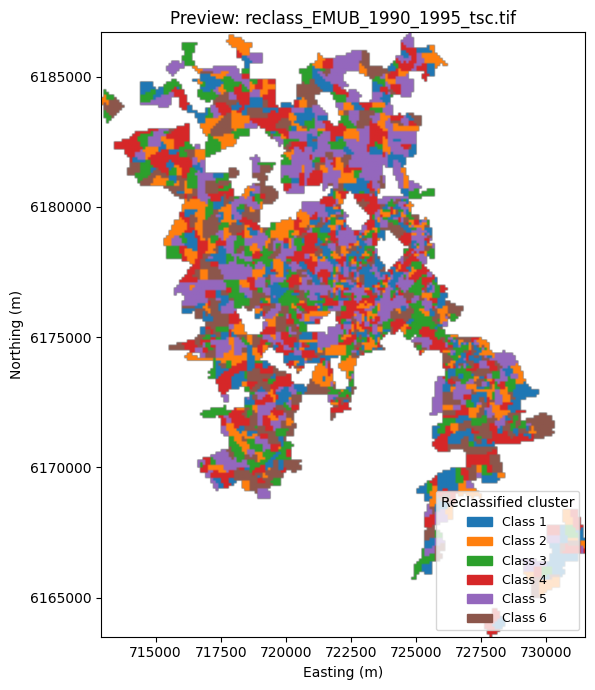

Unique values (0=nodata): [0, 1, 2, 3, 4, 5, 6]
CRS: EPSG:25832   Size: 186 x 232 px


In [20]:

# ── Cell 7: Preview one reclassified raster ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import rasterio
import numpy as np

PREVIEW_FILE = OUTPUT_DIR / 'reclass_EMUB_1990_1995_tsc.tif'

with rasterio.open(PREVIEW_FILE) as src:
    data    = src.read(1).astype(float)
    extent  = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    preview_crs  = src.crs
    preview_size = (src.width, src.height)

# Mask nodata (0) as NaN for display
data_masked = np.where(data == 0, np.nan, data)

# Discrete colormap for values 1–6
cmap = mcolors.ListedColormap(plt.cm.tab10.colors[:6])
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], ncolors=6)

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(data_masked, cmap=cmap, norm=norm, extent=extent, origin='upper')

# Legend patches
patches = [mpatches.Patch(color=cmap.colors[i], label=f'Class {i+1}') for i in range(6)]
ax.legend(handles=patches, loc='lower right', title='Reclassified cluster', fontsize=9)

ax.set_title(f'Preview: {PREVIEW_FILE.name}', fontsize=12)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.ticklabel_format(style='plain', axis='both')
plt.tight_layout()
plt.show()

print(f'Unique values (0=nodata): {sorted(np.unique(data.astype(int)).tolist())}')
print(f'CRS: {preview_crs}   Size: {preview_size[0]} x {preview_size[1]} px')
